# Heaps' Law analysis of Claude-bootstrap label vocabulary

Reads the per-experiment `features_candidate` + `features_status`
databases produced by `bin/llm_annotate_features` and plots the
cumulative-distinct-labels curve as treatments are processed in
temporal order.  Tells you whether you've collected enough
treatments to see a stable feature vocabulary, or whether more
bootstrap runs are still discovering new labels.

Three views:

1. **Raw**: distinct labels exactly as Claude returned them.
   Includes drift duplicates (`Odor` + `Odour`, `Partial_veil_microstructure`
   + `Partial_veil_(microscopic)`, etc.) — over-counts the real
   vocabulary.
2. **Canonical**: drift collapsed via a hand-edited mapping
   (`docs/feature_label_canonicalization.json`).  Closer to the
   true biological vocabulary.
3. **Hand-reviewed**: the `features_hand` DB — what the human
   reviewer actually kept.  Ground truth, when it exists.

Also reports cost / performance from the `metrics` sub-doc
(wall-clock, API latency, input/output tokens) once an
instrumented run has been done.

Re-run any time after a fresh `bin/llm_annotate_features` pass.

## Setup

In [1]:
# Path setup so the notebook can import skol modules.
import sys
from pathlib import Path
# Walk up from CWD until we find the skol repo root
# (identified by the bin/env_config.py marker).  Robust
# to the notebook being in jupyter/, notebooks/, or any
# other subdirectory.
_p = Path.cwd().resolve()
while not (_p / 'bin' / 'env_config.py').exists():
    if _p == _p.parent:  # reached filesystem root
        raise RuntimeError(
            f'could not find skol repo root from {Path.cwd()!r}'
        )
    _p = _p.parent
SKOL_ROOT = _p
sys.path.insert(0, str(SKOL_ROOT))
sys.path.insert(0, str(SKOL_ROOT / 'bin'))

import json
from collections import defaultdict, Counter
from typing import Any, Dict, List, Optional, Tuple

import couchdb
import matplotlib.pyplot as plt
import numpy as np

# Use skol's env_config so the connection settings match what the
# CLI tools use (no need to duplicate the URL / credentials here).
from env_config import get_env_config

# --- Configuration: edit these to retarget the notebook ---
EXPERIMENT = 'production_v4'
CANONICALIZATION_PATH = (
    SKOL_ROOT / 'docs' / 'feature_label_canonicalization.json'
)
# ----------------------------------------------------------

class _Args:
    pass
_args = _Args()
_args.experiment = EXPERIMENT
config = get_env_config(cli_args=_args)
server = couchdb.Server(config['couchdb_url'])
server.resource.credentials = (
    config['couchdb_username'], config['couchdb_password'],
)
print(f'Connected to {config["couchdb_url"]}; experiment = {EXPERIMENT!r}')

Connected to http://localhost:5984; experiment = 'production_v4'


## Load annotations + status docs

Loads everything for the experiment in two queries — annotations
(for the Heaps' Law curve) and status docs (for the metrics).
Treatment order comes from the annotations' `created_at` (set once
per Claude call, shared by all annotations from that call).

In [2]:
def load_candidate_annotations(experiment: str) -> List[Dict[str, Any]]:
    # Fallback naming convention; matches bin/llm_annotate_features.
    db_name = f'skol_exp_{experiment}_02_50_features_candidate'
    if db_name not in server:
        raise RuntimeError(
            f'{db_name!r} not found — run bin/llm_annotate_features first'
        )
    rows = server[db_name].view('_all_docs', include_docs=True).rows
    return [dict(r.doc) for r in rows if r.doc is not None]


def load_status_docs(experiment: str) -> List[Dict[str, Any]]:
    db_name = f'skol_exp_{experiment}_02_50_features_status'
    if db_name not in server:
        return []  # pre-Design-Y data; downstream cells degrade gracefully
    rows = server[db_name].view('_all_docs', include_docs=True).rows
    return [dict(r.doc) for r in rows if r.doc is not None]


def load_hand_annotations(experiment: str) -> List[Dict[str, Any]]:
    # Optional: features_hand may not exist yet.  Downstream cells
    # degrade gracefully.
    db_name = f'skol_exp_{experiment}_02_55_features_hand'
    if db_name not in server:
        return []
    rows = server[db_name].view('_all_docs', include_docs=True).rows
    return [dict(r.doc) for r in rows if r.doc is not None]


# F2 --- the candidate DB holds every round, so an unfiltered load
# mixes the biased rounds 1-4 into a curve meant to describe a random
# one.  `round` is stamped on every doc as of T0e, so this is a field
# test rather than a file join.  Set ROUND = None to see everything.
ROUND = 5

# Round 5's *drawn* population is the round file.  The manual canary
# taxon_46ff7dde is stamped round 5 too but was hand-picked, so it is
# excluded from the statistics by operator decision.
ROUND_FILE = (
    SKOL_ROOT / 'data' / 'annotation_rounds'
    / f'{EXPERIMENT}_round{ROUND}.txt'
) if ROUND else None
DRAWN = [
    line.strip()
    for line in ROUND_FILE.read_text().splitlines() if line.strip()
] if ROUND_FILE and ROUND_FILE.exists() else []

# Kept unfiltered for the hand-review comparison further down: every
# reviewed treatment is from rounds 1-4, so scoping that cell to a
# single round would compare an empty candidate set against 318 hand
# labels and report all of them as "Claude missed".
all_annotations = load_candidate_annotations(EXPERIMENT)
annotations = list(all_annotations)
if ROUND is not None:
    before = len(annotations)
    annotations = [a for a in annotations if a.get('round') == ROUND]
    if DRAWN:
        drawn_set = set(DRAWN)
        annotations = [
            a for a in annotations
            if a.get('treatment_id') in drawn_set
        ]
    print(f'  round filter: {before} -> {len(annotations)} annotations')
status_docs = load_status_docs(EXPERIMENT)
hand_annotations = load_hand_annotations(EXPERIMENT)
print(f'  candidate annotations: {len(annotations)}')
print(f'  status docs:           {len(status_docs)}')
print(f'  hand-reviewed:         {len(hand_annotations)}')

  round filter: 9068 -> 7480 annotations


  candidate annotations: 7480
  status docs:           6637
  hand-reviewed:         2244


## Build first-seen-at dicts

For each label, find the earliest `created_at` across its
annotations.  Combined with the temporal ordering of treatments,
this gives the data structure that lets us plot the Heaps' Law
curve cheaply (and re-use for raw vs canonical comparisons).

In [3]:
from treatments_to_structured.heaps import (
    cumulative_curve,
    fit_beta,
    labels_by_treatment,
    permutation_band,
    timestamp_collisions,
)

# The guard the old curve silently depended on.  It grouped labels by
# `created_at` and added them for EVERY treatment sharing that string,
# so a collision both mis-attributed and double-counted.  Measured
# 2026-08-26: zero collisions -- latent, not active.  Checked anyway.
collisions = timestamp_collisions(annotations)
assert not collisions, f'{len(collisions)} shared created_at: {collisions}'

by_treatment = labels_by_treatment(annotations)
# The canonical grouping waits for cell 8, which loads the map.

# The population to plot against is what was DRAWN, not what produced
# labels: a treatment that yielded nothing was still sampled, and
# dropping it shortens the x-axis and steepens the curve.  Round 5:
# 1 000 drawn, 877 with labels.
population = DRAWN or sorted(by_treatment)

# F1 --- the temporal order is an artefact.  `created_at` is stamped
# AFTER client.messages.create returns, so it is completion order.
# Kept only as the secondary panel below.
first_at = {}
for ann in annotations:
    tid, ts = ann.get('treatment_id'), ann.get('created_at')
    if tid and ts and (tid not in first_at or ts < first_at[tid]):
        first_at[tid] = ts
temporal_order = [t for t, _ in sorted(first_at.items(), key=lambda kv: kv[1])]
temporal_order += [t for t in population if t not in first_at]

print(f'drawn:            {len(population)}')
print(f'produced labels:  {len(by_treatment)}')
print(f'raw vocabulary:   {len(set().union(*by_treatment.values()))}')


drawn:            1000
produced labels:  876
raw vocabulary:   957


## Canonicalization

Load the hand-edited drift mapping if it exists; fall back to an
empty identity map (raw == canonical, useful baseline for new
experiments).  The file format is

```json
{ "raw_label": "canonical_label", ... }
```

Absent keys are identity (`raw_label` is already canonical),
so the file only documents the drift cases and stays compact.

To grow the mapping: paste new drift entries from the
`annotation.conf` produced by `bin/brat_export` after each
bootstrap run.

In [4]:
# The canonical curve now goes through the same entry point the
# writers use: the hand map first, then the rule-shaped families
# feature_label_rules settles (the sexual/asexual head noun, for
# one).  A dict cannot express a rule, which is why
# labels_by_treatment takes a callable as well as a Mapping.
from treatments_to_structured.feature_label_rules import (
    canonicalize,
    load_canonicalization,
)

canonicalization = load_canonicalization()  # docs/feature_label_canonicalization.json


def canonical(label: str) -> str:
    return canonicalize(label, canonicalization)


by_treatment_canonical = labels_by_treatment(
    annotations, canonicalizer=canonical,
)

# Vocabularies as sets, not timestamp-keyed dicts.  The old
# `label_first_seen_at` form is gone: it existed only to feed a curve
# that keyed on `created_at`, which is the bug this notebook pass
# removed.
raw_vocab = set().union(*by_treatment.values()) if by_treatment else set()
canonical_vocab = (
    set().union(*by_treatment_canonical.values())
    if by_treatment_canonical else set()
)
drift_pairs = sum(
    1 for raw, canon in canonicalization.items() if raw != canon
)
# What the rules move that the map does not -- zero means the map has
# caught up with the corpus, not that the rules are inert.
by_rule = sorted(
    label for label in raw_vocab
    if label not in canonicalization and canonical(label) != label
)
print(f'canonicalization entries: {len(canonicalization)} '
      f'({drift_pairs} non-identity)')
print(f'moved by rule, not by map: {len(by_rule)} {by_rule[:8]}')
print(f'raw distinct labels:       {len(raw_vocab)}')
print(f'canonical distinct labels: {len(canonical_vocab)}')
if raw_vocab:
    drift_fraction = 1 - (len(canonical_vocab) / len(raw_vocab))
    print(f'drift fraction (raw -> canonical): {drift_fraction:.1%}')


canonicalization entries: 55 (55 non-identity)
moved by rule, not by map: 0 []
raw distinct labels:       957
canonical distinct labels: 934
drift fraction (raw -> canonical): 2.4%


## Heaps' Law curve

Plot cumulative-distinct-labels-seen vs treatments-processed in
temporal order.  Compare raw and canonical curves on the same
axes — the gap between them is the drift overhead.

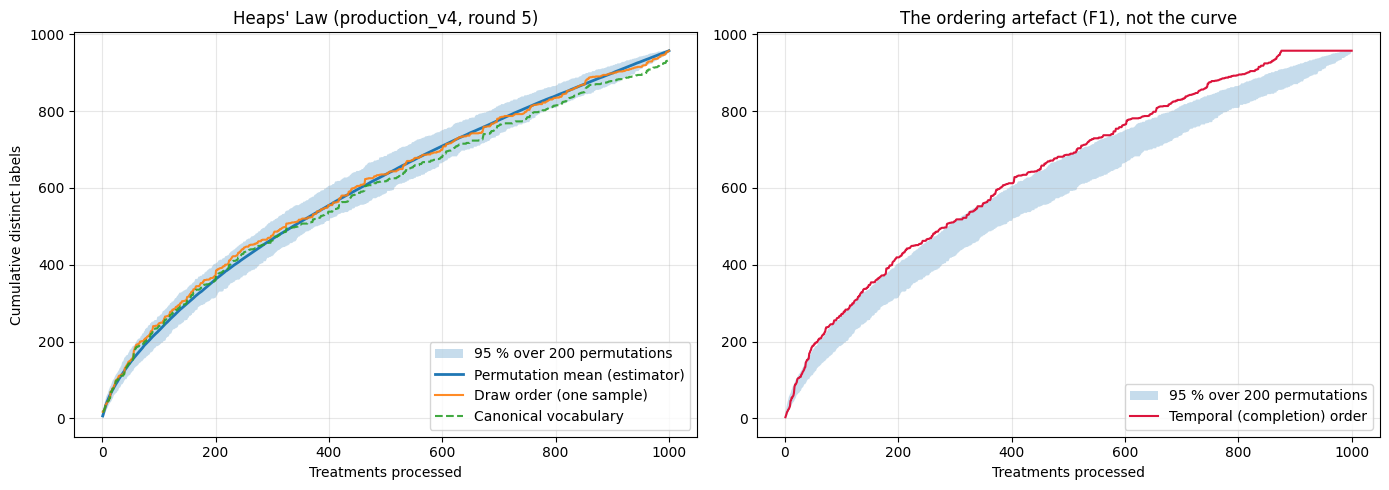

beta  permutation 0.601  (the estimate, n >= 200;  K = 15.17)
      draw order  0.568
      temporal    0.547  (artefact)
      from n=1    0.645  (head-inflated, NOT the estimate)
hapax fraction    0.580  (555/957 types seen once) -- should track beta
temporal curve outside the band at 873/1000 points


In [5]:
import collections

from treatments_to_structured.heaps import fit_beta

xs_draw, ys_draw = cumulative_curve(population, by_treatment)
xs_can, ys_can = cumulative_curve(population, by_treatment_canonical)
xs_temp, ys_temp = cumulative_curve(temporal_order, by_treatment)
xs_band, band_mean, band_lo, band_hi = permutation_band(
    by_treatment, n_permutations=200, ids=population,
)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax.fill_between(xs_band, band_lo, band_hi, alpha=0.25,
                label='95 % over 200 permutations')
ax.plot(xs_band, band_mean, '-', lw=2, label='Permutation mean (estimator)')
ax.plot(xs_draw, ys_draw, '-', alpha=0.9, label='Draw order (one sample)')
ax.plot(xs_can, ys_can, '--', alpha=0.9, label='Canonical vocabulary')
ax.set_xlabel('Treatments processed')
ax.set_ylabel('Cumulative distinct labels')
ax.set_title(f"Heaps' Law ({EXPERIMENT}, round {ROUND})")
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Secondary panel: the ordering artefact itself.  This answers a
# different question -- did the model's vocabulary drift DURING the
# run -- and must not be read as the Heaps curve.
ax2.fill_between(xs_band, band_lo, band_hi, alpha=0.25,
                 label='95 % over 200 permutations')
ax2.plot(xs_temp, ys_temp, '-', color='crimson',
         label='Temporal (completion) order')
ax2.set_xlabel('Treatments processed')
ax2.set_title('The ordering artefact (F1), not the curve')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# beta is fitted where the power law holds.  The head of the curve is
# not Heaps -- at n=1 every label is new, so V tracks n and the slope
# approaches 1 -- so fitting from the origin overstates growth and
# would demand more sampling than the corpus needs.  fit_beta lives in
# treatments_to_structured.heaps with tests; FIT_MIN_N is the window.
FIT_MIN_N = 200

k_band, beta_band = fit_beta(xs_band, band_mean, min_n=FIT_MIN_N)
_, beta_draw = fit_beta(xs_draw, ys_draw, min_n=FIT_MIN_N)
_, beta_temp = fit_beta(xs_temp, ys_temp, min_n=FIT_MIN_N)
_, beta_head = fit_beta(xs_band, band_mean, min_n=1)

print(f'beta  permutation {beta_band:.3f}  (the estimate, '
      f'n >= {FIT_MIN_N};  K = {k_band:.2f})')
print(f'      draw order  {beta_draw:.3f}')
print(f'      temporal    {beta_temp:.3f}  (artefact)')
print(f'      from n=1    {beta_head:.3f}  (head-inflated, NOT the '
      f'estimate)')

# Cross-check with no functional form: for a Zipf/Heaps process the
# singleton fraction converges to beta.  If these two disagree, the
# power-law fit is describing something else.
_df = collections.Counter(
    label for labels in by_treatment.values() for label in labels
)
_hapax = sum(1 for count in _df.values() if count == 1)
print(f'hapax fraction    {_hapax / len(_df):.3f}  '
      f'({_hapax}/{len(_df)} types seen once) -- should track beta')

outside = sum(1 for i in range(len(xs_band))
              if not band_lo[i] <= ys_temp[i] <= band_hi[i])
print(f'temporal curve outside the band at {outside}/{len(xs_band)} points')


## Growth statistics

Two numbers worth tracking:

- **Slope at endpoint** — new labels per treatment in the most
  recent run.  If high, we're still discovering; if near 0, the
  vocabulary has plateaued for this corpus.
- **Drift ratio** — `1 - canonical/raw`.  How much of the
  apparent vocabulary growth is LLM normalization noise vs real
  new features.  High = canonicalization step is urgent.

In [6]:
def endpoint_slope(xs: List[int], ys: List[int], window: int = 10) -> float:
    """Slope of the last `window` treatments, in new-labels-per-treatment."""
    if len(xs) < 2:
        return 0.0
    k = min(window, len(xs))
    dx = xs[-1] - xs[-k]
    dy = ys[-1] - ys[-k]
    if dx == 0:
        return 0.0
    return dy / dx


def avg_labels_per_treatment(by_treatment: Dict[str, set]) -> float:
    """Distinct labels per treatment, over the treatments that produced
    any.  Uses the same grouping the curve does, rather than a second
    copy of it."""
    if not by_treatment:
        return 0.0
    return sum(len(v) for v in by_treatment.values()) / len(by_treatment)


def print_growth_stats() -> None:
    print(f'Treatments drawn:      {len(population)}')
    print(f'  ...producing labels: {len(by_treatment)}')
    print(f'')
    print(f'  RAW vocabulary')
    print(f'    Distinct labels:          {len(raw_vocab)}')
    print(f'    Avg labels per treatment: '
          f'{avg_labels_per_treatment(by_treatment):.1f}')
    print(f'    Endpoint slope (last 10): '
          f'{endpoint_slope(xs_band, band_mean):.2f} new/treatment')
    print(f'      (from the permutation mean -- the draw order is one')
    print(f'       sample and its endpoint slope is noisy)')
    print(f'')
    print(f'  CANONICAL vocabulary')
    print(f'    Distinct labels:          {len(canonical_vocab)}')
    print(f'    Avg labels per treatment: '
          f'{avg_labels_per_treatment(by_treatment_canonical):.1f}')
    print(f'    Endpoint slope (last 10): '
          f'{endpoint_slope(xs_can, ys_can):.2f} new/treatment')
    print(f'')
    singletons = sum(
        1 for _, k in Counter(
            lbl for v in by_treatment.values() for lbl in v
        ).items() if k == 1
    )
    print(f'  Singleton labels: {singletons}/{len(raw_vocab)} '
          f'({singletons / max(len(raw_vocab), 1):.0%})')
    print(f'')
    if raw_vocab and canonical_vocab:
        drift = 1 - (len(canonical_vocab) / len(raw_vocab))
        print(f'  Drift fraction (raw → canonical): {drift:.1%}')
        if drift > 0.2:
            print('    ↑ HIGH — label canonicalization is urgent before scaling up')
        elif drift > 0.05:
            print('    moderate — canonicalize when convenient')
        else:
            print('    low — drift is not contributing much to vocabulary growth')


print_growth_stats()

Treatments drawn:      1000
  ...producing labels: 876

  RAW vocabulary
    Distinct labels:          957
    Avg labels per treatment: 7.2
    Endpoint slope (last 10): 0.58 new/treatment
      (from the permutation mean -- the draw order is one
       sample and its endpoint slope is noisy)

  CANONICAL vocabulary
    Distinct labels:          934
    Avg labels per treatment: 7.2
    Endpoint slope (last 10): 1.00 new/treatment

  Singleton labels: 555/957 (58%)

  Drift fraction (raw → canonical): 2.4%
    low — drift is not contributing much to vocabulary growth


## Hand-reviewed vocabulary

After a brat-review round, the `features_hand` DB carries the
labels the reviewer actually kept (plus anything they added).
Three comparisons against the bootstrap output:

- **Vocabulary size**: how many distinct labels survived review,
  raw and canonical.
- **Reviewer disagreement**: what fraction of bootstrap labels
  were rejected.  High = bootstrap prompt needs work.
- **Reviewer additions**: what fraction of final labels were
  invented by the reviewer (not in any Claude output).
  High = bootstrap missed important features.

In [7]:
# NOTE: this cell uses `all_annotations`, not the round-filtered
# `annotations`.  Hand review has only ever covered rounds 1-4, so
# comparing against one round's candidates would score every hand
# label as a miss.
if not hand_annotations:
    print('No features_hand DB yet — run bin/brat_ingest after a brat review.')
else:
    # Scope the comparison to treatments that have BOTH a candidate
    # and a hand annotation.  Without this scoping, 'rejected' would
    # include every label from every UN-reviewed treatment in the
    # candidate DB — which isn't rejection, just deferred review.
    # Under the correct scoping, 'rejected' means: 'a label the
    # reviewer saw during hand-review and chose not to keep.'
    reviewed_tids = {
        a['treatment_id']
        for a in hand_annotations
        if 'treatment_id' in a
    }
    scoped_candidate = [
        a for a in all_annotations
        if a.get('treatment_id') in reviewed_tids
    ]

    candidate_labels_all = {a['feature_label'] for a in all_annotations}
    candidate_labels = {a['feature_label'] for a in scoped_candidate}
    hand_labels = {a['feature_label'] for a in hand_annotations}
    canon_candidate = {canonicalization.get(l, l) for l in candidate_labels}
    canon_hand = {canonicalization.get(l, l) for l in hand_labels}

    # Reviewer actions breakdown via the reviewer_action field
    # (kept / added; deleted annotations don't appear in features_hand).
    action_counts = Counter(
        a.get('reviewer_action', 'unknown') for a in hand_annotations
    )

    all_tids = {
        a['treatment_id']
        for a in all_annotations
        if 'treatment_id' in a
    }
    print(
        f'Treatments: {len(reviewed_tids)} reviewed / '
        f'{len(all_tids)} total in candidate DB '
        f'({len(all_tids - reviewed_tids)} awaiting review)'
    )
    print()
    print('Vocabulary — scoped to REVIEWED treatments only')
    print(f'  Candidate (raw, reviewed only):     {len(candidate_labels)}')
    print(f'  Candidate (canonical, reviewed):    {len(canon_candidate)}')
    print(f'  Hand (raw):                         {len(hand_labels)}')
    print(f'  Hand (canonical):                   {len(canon_hand)}')
    print()
    print(
        f'For context: candidate has {len(candidate_labels_all)} '
        f'raw labels total across all treatments; the extras '
        f'({len(candidate_labels_all - candidate_labels)}) come from '
        f'unreviewed treatments and are not evaluated here.'
    )
    print()
    print('Reviewer actions on bootstrap annotations')
    for action, n in action_counts.most_common():
        print(f'  {action:<10} {n}')

    # Labels the reviewer added that Claude never produced (scoped
    # to reviewed treatments so this is honest).
    reviewer_only = canon_hand - canon_candidate
    # Labels Claude produced (in reviewed treatments) that the
    # reviewer kept zero of.  Real reviewer signal now.
    reviewer_rejected = canon_candidate - canon_hand
    print()
    print(
        f'Reviewer-only labels (Claude missed): {len(reviewer_only)}'
    )
    if reviewer_only:
        for lbl in sorted(reviewer_only):
            print(f'  + {lbl}')
    print(
        f'Rejected labels (Claude wrong, in reviewed treatments): '
        f'{len(reviewer_rejected)}'
    )
    if reviewer_rejected:
        for lbl in sorted(reviewer_rejected):
            print(f'  − {lbl}')

Treatments: 147 reviewed / 986 total in candidate DB (839 awaiting review)

Vocabulary — scoped to REVIEWED treatments only
  Candidate (raw, reviewed only):     379
  Candidate (canonical, reviewed):    354
  Hand (raw):                         381
  Hand (canonical):                   355

For context: candidate has 1060 raw labels total across all treatments; the extras (681) come from unreviewed treatments and are not evaluated here.

Reviewer actions on bootstrap annotations
  kept       1927
  added      317

Reviewer-only labels (Claude missed): 3
  + Germ tubes
  + Squamules
  + Zygospores
Rejected labels (Claude wrong, in reviewed treatments): 2
  − Conidial germination
  − General veil


## Cost and performance (from `metrics` sub-doc)

The `bin/llm_annotate_features` instrumentation captures:

- `wall_clock_seconds` / `api_latency_seconds` — where time went
- `input_tokens` / `output_tokens` — measured cost basis
- `synth_doc_chars` — input-size predictor
- `complexity_score` — pre-computed predictor for annotation count

If most cells here show "no data", run a fresh bootstrap pass —
status docs from before the instrumentation landed don't carry
the `metrics` sub-dict.

In [8]:
metrics_rows = [
    d for d in status_docs if d.get('metrics')
]
print(f'{len(metrics_rows)}/{len(status_docs)} status docs carry metrics.')
if not metrics_rows:
    print('Run `bin/llm_annotate_features --experiment {} --force ...`'
          ' to regenerate with instrumentation.'.format(EXPERIMENT))

6637/6637 status docs carry metrics.


In [9]:
# Pull metrics into arrays for plotting.  Filter on presence
# rather than truthiness — 0.0 / 0 are legitimate values.
def col(rows, key):
    return [r['metrics'].get(key) for r in rows]


synth_chars = col(metrics_rows, 'synth_doc_chars')
api_latency = col(metrics_rows, 'api_latency_seconds')
wall_clock = col(metrics_rows, 'wall_clock_seconds')
input_tokens = col(metrics_rows, 'input_tokens')
output_tokens = col(metrics_rows, 'output_tokens')
complexity = col(metrics_rows, 'complexity_score')

# Defensive: drop any None entries before computing arrays.
def clean_pair(xs, ys):
    return [
        (x, y) for x, y in zip(xs, ys)
        if x is not None and y is not None
    ]


# Cost calibration: measured vs estimated output tokens.
if metrics_rows:
    in_out = [
        (i, o) for i, o in zip(input_tokens, output_tokens)
        if i is not None and o is not None
    ]
    if in_out:
        in_arr = np.array([p[0] for p in in_out])
        out_arr = np.array([p[1] for p in in_out])
        ratio = float(out_arr.mean() / in_arr.mean())
        print(f'Measured output/input token ratio (mean): {ratio:.2%}')
        from llm_annotate_features import OUTPUT_TOKEN_RATIO
print(f'  (the estimator assumes {OUTPUT_TOKEN_RATIO:.0%}; re-calibrate '
      f'bin/llm_annotate_features.OUTPUT_TOKEN_RATIO if these diverge)')

Measured output/input token ratio (mean): 30.18%
  (the estimator assumes 28%; re-calibrate bin/llm_annotate_features.OUTPUT_TOKEN_RATIO if these diverge)


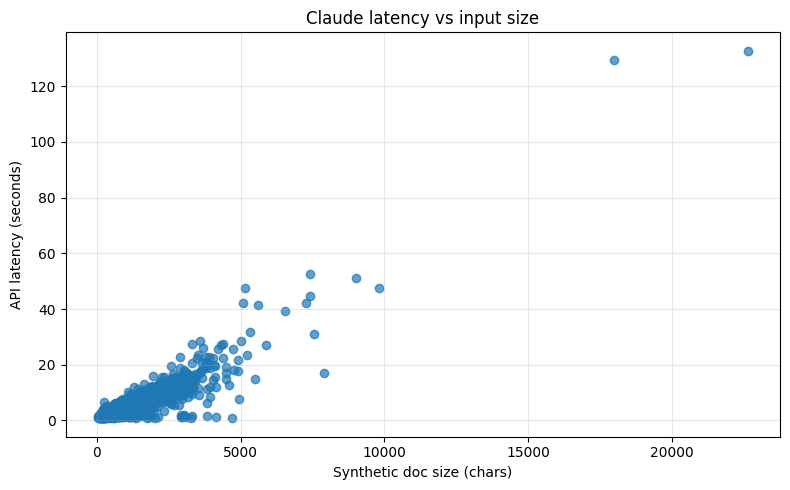

In [10]:
# Wall-clock vs synth-doc-chars (does longer input → longer call?)
pairs = clean_pair(synth_chars, api_latency)
if pairs:
    xs = [p[0] for p in pairs]
    ys = [p[1] for p in pairs]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(xs, ys, alpha=0.7)
    ax.set_xlabel('Synthetic doc size (chars)')
    ax.set_ylabel('API latency (seconds)')
    ax.set_title('Claude latency vs input size')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough instrumented runs yet.')

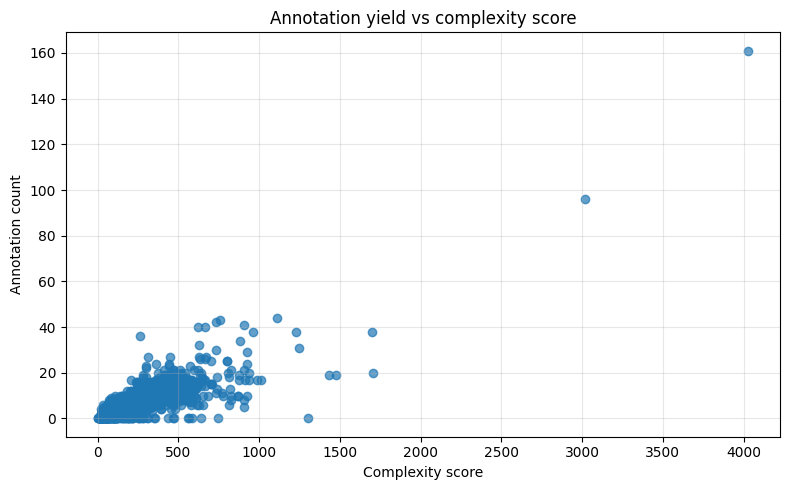

In [11]:
# Complexity score vs annotation count — does the complexity
# scorer predict how many features Claude will find?
if metrics_rows:
    annotation_count_by_tid = {
        d['treatment_id']: d.get('annotation_count', 0)
        for d in status_docs
    }
    pairs = [
        (d['metrics']['complexity_score'],
         annotation_count_by_tid.get(d['treatment_id'], 0))
        for d in metrics_rows
        if d['metrics'].get('complexity_score') is not None
    ]
    if pairs:
        xs = [p[0] for p in pairs]
        ys = [p[1] for p in pairs]
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(xs, ys, alpha=0.7)
        ax.set_xlabel('Complexity score')
        ax.set_ylabel('Annotation count')
        ax.set_title('Annotation yield vs complexity score')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Next steps

- **If raw curve is still steep at the end**: more treatments
  will keep producing new labels.  Either run more bootstrap
  (if drift is low) or canonicalize first (if drift fraction
  was high above).
- **If canonical curve has plateaued**: the bootstrap is done
  discovering.  Bottleneck is review labor, not coverage.
- **If reviewer-only labels are common**: bootstrap prompt is
  missing concepts; tweak the seed.
- **If reviewer rejection is common**: bootstrap is too eager;
  tweak the prompt to be more conservative.

Re-export the canonicalization mapping after each review round:

```bash
# Manual: open the annotation.conf from bin/brat_export, eyeball
# drift entries, add them to docs/feature_label_canonicalization.json.
```

## Multi-species merge detection: term-repetition metric

Real single-species treatments concentrate their technical
vocabulary within specific sections (one Pileus block, one
Stipe block, etc.), so each anatomical term appears a handful
of times.  Multi-species merged treatments (§6 in the data
quality memo) repeat the same section structure N times, so
each anatomical term gets N-fold boosted.

Metric: `n_terms_above_k` — count of distinct non-stop-word
terms appearing at least K times in the description+diagnosis
text.

Hypothesis: this metric correlates with the annotation count
that Claude produced.  If it does, a threshold on the metric
can be applied BEFORE the bootstrap pass to skip suspected
merges and save API budget.


In [12]:
from collections import Counter
import re

# Compact English stop-word list (avoids the NLTK dependency).
# Domain-specific additions come next: common mycology
# measurement units and structural markers that would confound
# the technical-term-repetition signal.
_STOP_WORDS = {
    "the", "of", "and", "in", "to", "or", "with", "on", "at",
    "by", "an", "as", "is", "are", "was", "were", "be", "been",
    "being", "not", "no", "this", "that", "these", "those", "it",
    "its", "for", "from", "up", "down", "into", "out", "over",
    "under", "after", "before", "then", "than", "so", "such",
    "which", "when", "where", "who", "how", "what", "why",
    "some", "any", "all", "each", "every", "one", "two", "three",
    "four", "five", "more", "most", "less", "least", "very",
    "much", "many", "few", "also", "both", "either", "neither",
    "if", "but", "however", "although", "though", "while",
    "have", "has", "had", "having", "may", "might", "can",
    "could", "would", "should", "shall", "will", "do", "does",
    "did", "done", "there", "their", "them", "they", "he",
    "she", "his", "her", "him",
    # Domain-specific: measurement / structural noise.
    "mm", "cm", "um", "nm", "ul", "kpa", "wide", "long", "high",
    "thick", "diam", "diameter", "size", "cell", "cells",
    "wall", "walls", "base", "apex", "surface",
}
_TOKEN_RE = re.compile(r"[a-zA-Z]{3,}")


def n_terms_above_k(text, k=5, stop=None):
    """Number of distinct non-stop-word terms appearing >= k times."""
    stop = stop or _STOP_WORDS
    tokens = _TOKEN_RE.findall(text.lower())
    counts = Counter(t for t in tokens if t not in stop)
    return sum(1 for c in counts.values() if c >= k)


def top_terms(text, n=20, stop=None):
    """Top-n non-stop-word terms by frequency, as (term, count)."""
    stop = stop or _STOP_WORDS
    tokens = _TOKEN_RE.findall(text.lower())
    counts = Counter(t for t in tokens if t not in stop)
    return counts.most_common(n)


# Load treatments_prose docs for every treatment we have status
# info for.  Batch by _id from the status docs to avoid scanning
# all 81k docs.
treatments_db = server[f"skol_exp_{EXPERIMENT}_02_00_treatments_prose"]
tids = sorted(d["treatment_id"] for d in status_docs)

metric_rows = []
for tid in tids:
    try:
        doc = treatments_db[tid]
    except Exception:
        continue
    text = " ".join(
        (doc.get(f) or "") for f in ("description", "diagnosis")
    )
    if not text.strip():
        continue
    metric_rows.append({
        "treatment_id": tid,
        "text": text,
        "n_terms_above_5": n_terms_above_k(text, k=5),
        "text_length": len(text),
    })

# Cross-reference with annotation counts from status docs.
_ann_count = {
    d["treatment_id"]: d.get("annotation_count", 0)
    for d in status_docs
}
for row in metric_rows:
    row["annotation_count"] = _ann_count.get(row["treatment_id"], 0)

print(f"Computed metric for {len(metric_rows)} treatments")


Computed metric for 6637 treatments


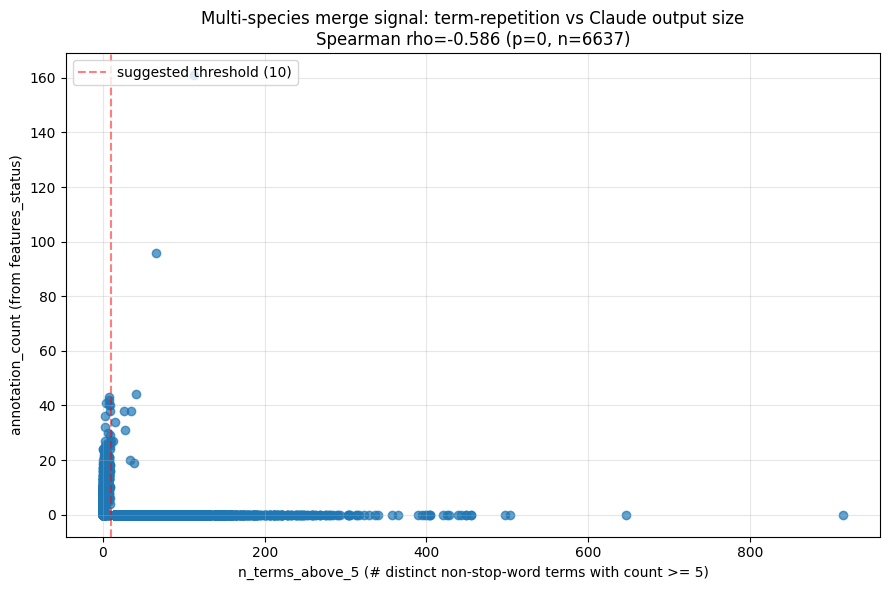

Threshold at n_terms_above_5 >= 15:
  above: 5529 treatments, annotation_count avg 0.1, max 161
  below: 1106 treatments, annotation_count avg 7.7, max 43


In [13]:
# The threshold is configuration as of 2026-08-26 -- CLI, then
# MERGE_THRESHOLD, then the config file, then
# merge_metric.DEFAULT_MERGE_THRESHOLD.  It moved 10 -> 15 after 30
# hand verdicts put precision at 10 at 51.7 %; memo section 6.1.
MERGE_THRESHOLD = config['merge_threshold']

from scipy.stats import spearmanr

xs = [r["n_terms_above_5"] for r in metric_rows]
ys = [r["annotation_count"] for r in metric_rows]

rho, p = spearmanr(xs, ys)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(xs, ys, alpha=0.7)
ax.set_xlabel("n_terms_above_5 (# distinct non-stop-word terms with count >= 5)")
ax.set_ylabel("annotation_count (from features_status)")
ax.set_title(
    f"Multi-species merge signal: term-repetition vs Claude output size\n"
    f"Spearman rho={rho:.3f} (p={p:.3g}, n={len(xs)})"
)
ax.grid(True, alpha=0.3)

# Highlight the suggested threshold at n_terms_above_5 = 10 for
# visual reference.
ax.axvline(10, color="red", linestyle="--", alpha=0.5,
           label="suggested threshold (10)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# What annotation-count range does the threshold predict?
above = [r for r in metric_rows if r["n_terms_above_5"] >= MERGE_THRESHOLD]
below = [r for r in metric_rows if r["n_terms_above_5"] < 10]
print(f"Threshold at n_terms_above_5 >= {MERGE_THRESHOLD}:")
print(f"  above: {len(above)} treatments, "
      f"annotation_count avg {sum(r['annotation_count'] for r in above) / max(1, len(above)):.1f}, "
      f"max {max((r['annotation_count'] for r in above), default=0)}")
print(f"  below: {len(below)} treatments, "
      f"annotation_count avg {sum(r['annotation_count'] for r in below) / max(1, len(below)):.1f}, "
      f"max {max((r['annotation_count'] for r in below), default=0)}")


In [14]:
# Show the top-20 non-stop terms for the highest-metric treatments
# so the operator can eyeball whether the signal is picking up
# repeated-section-structure vs some other noise.
top_by_metric = sorted(
    metric_rows, key=lambda r: r["n_terms_above_5"], reverse=True,
)[:5]

for row in top_by_metric:
    print(f"treatment_id: {row['treatment_id']}")
    print(f"  n_terms_above_5: {row['n_terms_above_5']}, "
          f"annotation_count: {row['annotation_count']}, "
          f"text_length: {row['text_length']} chars")
    print(f"  top 20 non-stop terms:")
    for term, cnt in top_terms(row["text"], n=20):
        print(f"    {cnt:>4}  {term}")
    print()


treatment_id: taxon_a728c78cf5db1f266b1eb159e31f23d427a42af7bf0df7e754ee4ff606209b39
  n_terms_above_5: 915, annotation_count: 0, text_length: 400867 chars
  top 20 non-stop terms:
     773  koh
     633  brown
     623  hyphae
     543  peridium
     493  spores
     442  hyaline
     403  gleba
     364  dried
     345  melzer
     343  sol
     342  walled
     299  fresh
     299  thin
     284  olive
     270  color
     270  layer
     267  yellow
     254  basidiocarps
     253  species
     249  yellowish

treatment_id: taxon_fd90008958c9c9fc08f360727b9ec30c53ef56c12446f62671d7310e3b0c74db
  n_terms_above_5: 647, annotation_count: 0, text_length: 189650 chars
  top 20 non-stop terms:
     319  pileus
     234  stipe
     200  white
     185  hyphae
     165  latex
     164  cuticle
     144  pale
     143  lamellae
     133  buff
     131  acrid
     130  margin
     122  spores
     122  yellow
     120  becoming
     119  color
     114  viscid
     112  trama
     109  taste